# Real-Time Surgical Instrument Segmentation and Tracking (CholecT50)

## 1. Setup & Environment Installation

In [1]:
# Install dependencies
!pip install -q albumentations numpy opencv-python-headless PyYAML torch torchvision ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.5 MB/s eta 0:00:00


In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# Define global path to your dataset folder in Google Drive or local storage
DATASET_PATH = '/content/drive/MyDrive/CV_Tasks/cholect50-challenge-val'
print(f'Global dataset path set to: {DATASET_PATH}')

Global dataset path set to: /content/drive/MyDrive/CV_Tasks/cholect50-challenge-val


## 2. Configuration Generator

generate the configuration directory structure and the standard YAML config files for **CholecT50** (with 6 classes: grasper, bipolar, hook, scissors, clipper, irrigator).

In [9]:
import os
import yaml

# Create configs directory structure
os.makedirs('configs/dataset', exist_ok=True)
os.makedirs('configs/training', exist_ok=True)
os.makedirs('configs/evaluation', exist_ok=True)
os.makedirs('configs/inference', exist_ok=True)
os.makedirs('configs/tracking', exist_ok=True)

# Write configs/dataset/cholect50.yaml
with open('configs/dataset/cholect50.yaml', 'w') as f:
    yaml.dump({
        'dataset': {
            'name': 'cholect50_phase1',
            'output_root': 'data/cholect50_phase1',
            'class_names': ['grasper', 'bipolar', 'hook', 'scissors', 'clipper', 'irrigator'],
            'splits': {'train': 0.6, 'val': 0.2, 'test': 0.2},
            'image_extensions': ['.png'],
            'mask_extensions': ['.png'],
            'ignore_mask_values': [0]
        }
    }, f)

# Write configs/training/yolo_seg_small.yaml
with open('configs/training/yolo_seg_small.yaml', 'w') as f:
    yaml.dump({
        'experiment': {
            'name': 'yolo_seg_cholect50_small',
            'output_root': 'outputs/train'
        },
        'dataset': {
            'prepared_root': 'data/cholect50_phase1',
            'yolo_dataset_yaml': 'data/cholect50_phase1/dataset.yaml'
        },
        'model': {
            'checkpoint': 'yolo11n-seg.pt',
            'image_size': 640,
            'epochs': 50,
            'batch_size': 4,
            'device': 'auto',
            'workers': 2,
            'patience': 20,
            'project': 'outputs/train',
            'run_name': 'yolo_seg_cholect50_small',
            'save_period': 5
        },
        'augmentation': {
            'hsv_h': 0.015,
            'hsv_s': 0.7,
            'hsv_v': 0.4,
            'degrees': 5.0,
            'translate': 0.05,
            'scale': 0.1,
            'shear': 2.0,
            'perspective': 0.0,
            'flipud': 0.0,
            'fliplr': 0.5,
            'mosaic': 0.0,
            'mixup': 0.0,
            'copy_paste': 0.0,
            'erasing': 0.15
        }
    }, f)

# Write configs/evaluation/segmentation_eval.yaml
with open('configs/evaluation/segmentation_eval.yaml', 'w') as f:
    yaml.dump({
        'dataset': {
            'prepared_root': 'data/cholect50_phase1',
            'split': 'val'
        },
        'predictions': {
            'root': 'outputs/predictions/val'
        },
        'report': {
            'output_path': 'outputs/reports/segmentation_eval.json'
        }
    }, f)

# Write configs/inference/video_demo.yaml
with open('configs/inference/video_demo.yaml', 'w') as f:
    yaml.dump({
        'runtime': {
            'device': 'auto',
            'image_size': 640,
            'conf_threshold': 0.25,
            'iou_threshold': 0.45,
            'max_frames': -1
        },
        'model': {
            'checkpoint': 'yolo11n-seg.pt'
        },
        'tracking': {
            'max_lost_frames': 15,
            'min_confidence': 0.2,
            'match_iou_threshold': 0.25,
            'max_center_distance': 150.0,
            'smoothing_alpha': 0.6,
            'enable_smoothing': True
        },
        'output': {
            'root': 'outputs/demo',
            'save_video': True,
            'save_frame_predictions': True,
            'video_codec': 'mp4v'
        }
    }, f)

# Write configs/tracking/tracker.yaml
with open('configs/tracking/tracker.yaml', 'w') as f:
    yaml.dump({
        'tracking': {
            'max_lost_frames': 15,
            'min_confidence': 0.2,
            'match_iou_threshold': 0.25,
            'max_center_distance': 150.0,
            'smoothing_alpha': 0.6,
            'enable_smoothing': True
        }
    }, f)

print('CholecT50 configuration files written successfully.')

CholecT50 configuration files written successfully.


## 3. Consolidated Codebase (Core Library)
load all libraries, config interfaces, dataset parsers (specifically adapted for CholecT50 labels), trackers, evaluation metrics, and frame-by-frame inference loops directly into Colab memory.

In [20]:
from __future__ import annotations
import sys
import json
import time
import cv2
import numpy as np
import yaml
import os
from pathlib import Path
from typing import Any, Iterable
from dataclasses import dataclass, field

try:
    import torch
except ImportError:
    torch = None

try:
    from ultralytics import YOLO
except ImportError:
    YOLO = None

# ==========================================
# 1. Preprocessing & Artifact Simulations
# ==========================================
def enhance_frame(frame: np.ndarray) -> np.ndarray:
    """Applies bilateral filtering and CLAHE to enhance contrast and reduce noise."""
    denoised = cv2.bilateralFilter(frame, (5,5), 0)
    lab = cv2.cvtColor(denoised, cv2.COLOR_BGR2LAB)
    l_channel, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l_channel)
    merged = cv2.merge((cl, a, b))
    return cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

def add_synthetic_smoke(image: np.ndarray, density: float = 0.6) -> np.ndarray:
    """Simulates laparoscopic smoke overlay."""
    h, w = image.shape[:2]
    noise = np.zeros((h // 4, w // 4), dtype=np.float32)
    cv2.randu(noise, 0, 255)
    noise = cv2.resize(noise, (w, h), interpolation=cv2.INTER_LINEAR)
    noise = cv2.GaussianBlur(noise, (41, 41), 0)
    noise = (noise - noise.min()) / (noise.max() - noise.min() + 1e-6)
    smoke_color = np.array([220, 220, 220], dtype=np.float32)
    smoke_layer = np.ones_like(image, dtype=np.float32) * smoke_color
    alpha = (noise * density)[:, :, np.newaxis]
    corrupted = image.astype(np.float32) * (1.0 - alpha) + smoke_layer * alpha
    return np.clip(corrupted, 0, 255).astype(np.uint8)

def add_synthetic_blood(image: np.ndarray, severity: float = 0.4) -> np.ndarray:
    """Simulates blood splatters on camera lens."""
    h, w = image.shape[:2]
    blood_mask = np.zeros((h, w), dtype=np.uint8)
    num_blobs = int(10 * severity)
    for _ in range(num_blobs):
        cx = np.random.randint(0, w)
        cy = np.random.randint(0, h)
        axes = (np.random.randint(20, 100), np.random.randint(10, 60))
        angle = np.random.randint(0, 180)
        cv2.ellipse(blood_mask, (cx, cy), axes, angle, 0, 360, 255, -1)
    blood_mask = cv2.GaussianBlur(blood_mask, (21, 21), 0)
    blood_color = np.array([15, 15, 140], dtype=np.uint8)
    blood_layer = np.ones_like(image, dtype=np.uint8) * blood_color
    alpha = (blood_mask / 255.0 * 0.75)[:, :, np.newaxis]
    corrupted = image.astype(np.float32) * (1.0 - alpha) + blood_layer.astype(np.float32) * alpha
    return np.clip(corrupted, 0, 255).astype(np.uint8)

def add_specular_reflection(image: np.ndarray, num_spots: int = 6) -> np.ndarray:
    """Simulates specular glare/reflections from metallic tool surfaces."""
    h, w = image.shape[:2]
    canvas = image.copy()
    for _ in range(num_spots):
        cx = np.random.randint(0, w)
        cy = np.random.randint(0, h)
        radius = np.random.randint(5, 20)
        mask = np.zeros((h, w), dtype=np.uint8)
        cv2.circle(mask, (cx, cy), radius, 255, -1)
        mask = cv2.GaussianBlur(mask, (15, 15), 0)
        alpha = (mask / 255.0)[:, :, np.newaxis]
        canvas = canvas.astype(np.float32) * (1.0 - 0.7 * alpha) + 255.0 * 0.7 * alpha
    return np.clip(canvas, 0, 255).astype(np.uint8)

def add_random_occlusion(image: np.ndarray, severity: float = 0.3) -> np.ndarray:
    """Simulates occlusion by organs/tissue."""
    h, w = image.shape[:2]
    canvas = image.copy()
    num_polys = int(4 * severity)
    for _ in range(num_polys):
        num_pts = np.random.randint(3, 6)
        pts = np.array([
            [np.random.randint(0, w), np.random.randint(0, h)]
            for _ in range(num_pts)
        ], dtype=np.int32)
        color = (np.random.randint(10, 40), np.random.randint(20, 60), np.random.randint(15, 45))
        cv2.fillPoly(canvas, [pts], color)
    return canvas

# ==========================================
# 2. Configuration & Utilities
# ==========================================
def load_config(path: str | Path) -> dict[str, Any]:
    config_path = Path(path)
    if not config_path.exists():
        raise FileNotFoundError(f'Config file not found: {config_path}')
    with config_path.open('r', encoding='utf-8') as handle:
        data = yaml.safe_load(handle) or {}
    if not isinstance(data, dict):
        raise ValueError(f'Config at {config_path} must deserialize to a mapping.')
    return data

def ensure_directory(path: str | Path) -> Path:
    directory = Path(path)
    directory.mkdir(parents=True, exist_ok=True)
    return directory

def resolve_path(root: str | Path, value: str | Path) -> Path:
    value_path = Path(value)
    if value_path.is_absolute():
        return value_path
    return Path(root) / value_path

# ==========================================
# 3. Runtime
# ==========================================
def resolve_device(device: Any) -> Any:
    if device not in (None, '', 'auto'):
        return device
    if torch is not None and torch.cuda.is_available():
        return 0
    return 'cpu'

# ==========================================
# 4. Reporting
# ==========================================
def write_json_report(path: str | Path, payload: dict[str, Any]) -> Path:
    output_path = Path(path)
    ensure_directory(output_path.parent)
    with output_path.open('w', encoding='utf-8') as handle:
        json.dump(payload, handle, indent=2)
    return output_path

# ==========================================
# 5. Metrics
# ==========================================
@dataclass(slots=True)
class SegmentationMetrics:
    iou: float
    dice: float
    precision: float
    recall: float

def compute_binary_segmentation_metrics(pred_mask: np.ndarray, gt_mask: np.ndarray) -> SegmentationMetrics:
    pred = pred_mask.astype(bool)
    truth = gt_mask.astype(bool)

    intersection = np.logical_and(pred, truth).sum()
    union = np.logical_or(pred, truth).sum()
    pred_sum = pred.sum()
    truth_sum = truth.sum()

    iou = float(intersection / union) if union else 1.0
    dice = float((2 * intersection) / (pred_sum + truth_sum)) if (pred_sum + truth_sum) else 1.0
    precision = float(intersection / pred_sum) if pred_sum else 1.0
    recall = float(intersection / truth_sum) if truth_sum else 1.0
    return SegmentationMetrics(iou=iou, dice=dice, precision=precision, recall=recall)

def aggregate_metrics(items: list[SegmentationMetrics]) -> dict[str, float]:
    if not items:
        return {'iou': 0.0, 'dice': 0.0, 'precision': 0.0, 'recall': 0.0, 'mIoU': 0.0}
    return {
        'iou': float(np.mean([item.iou for item in items])),
        'dice': float(np.mean([item.dice for item in items])),
        'precision': float(np.mean([item.precision for item in items])),
        'recall': float(np.mean([item.recall for item in items])),
        'mIoU': float(np.mean([item.iou for item in items])),
    }

def load_mask_file(path: Path) -> np.ndarray:
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise ValueError(f'Could not load mask: {path}')
    return (mask > 0).astype(np.uint8)

# ==========================================
# 6. Dataset Preparation (CholecT50 Bbox to Polygon conversion)
# ==========================================
def write_dataset_yaml(output_root: Path, class_names: list[str]) -> Path:
    dataset_yaml = output_root / 'dataset.yaml'
    lines = [
        f'path: {output_root.as_posix()}',
        'train: images/train',
        'val: images/val',
        'test: images/test',
        f'names: {class_names}',
    ]
    dataset_yaml.write_text('\n'.join(lines) + '\n', encoding='utf-8')
    return dataset_yaml

def prepare_cholect50_dataset(raw_root: Path, output_root: Path) -> dict[str, Any]:
    import json
    import cv2
    import numpy as np

    labels_dir = raw_root / 'labels'
    videos_dir = raw_root / 'videos'

    if not labels_dir.exists():
        raise FileNotFoundError(f'Labels directory not found: {labels_dir}')

    json_paths = sorted(list(labels_dir.glob('VID*.json')))
    if not json_paths:
        raise FileNotFoundError(f'No label JSON files found in {labels_dir}')

    splits = {
        'VID68': 'train',
        'VID70': 'train',
        'VID73': 'train',
        'VID74': 'val',
        'VID75': 'test'
    }

    class_names = ['grasper', 'bipolar', 'hook', 'scissors', 'clipper', 'irrigator']
    manifest = []

    for split in ['train', 'val', 'test']:
        ensure_directory(output_root / 'images' / split)
        ensure_directory(output_root / 'labels' / split)
        ensure_directory(output_root / 'masks' / split)

    for json_path in json_paths:
        video_id = json_path.stem
        split = splits.get(video_id, 'train')

        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        annotations = data.get('annotations', {})
        video_frames_dir = videos_dir / video_id

        print(f'Processing video: {video_id} ({split}) with {len(annotations)} annotated frames...')

        for frame_key, ann_list in annotations.items():
            frame_num = int(frame_key)
            frame_name = f'{frame_num:06d}.png'
            image_path = video_frames_dir / frame_name

            if not image_path.exists():
                image_path = video_frames_dir / f'{frame_key}.png'
                if not image_path.exists():
                    continue

            image = cv2.imread(str(image_path))
            if image is None:
                continue

            height, width = image.shape[:2]

            mask = np.zeros((height, width), dtype=np.uint8)
            polygons_by_class = {}

            for ann in ann_list:
                instrument_id = int(ann[1])

                if instrument_id < 0 or instrument_id >= len(class_names):
                    continue

                x1_norm = float(ann[3])
                y1_norm = float(ann[4])
                bw_norm = float(ann[5])
                bh_norm = float(ann[6])

                if x1_norm < 0 or y1_norm < 0 or bw_norm <= 0 or bh_norm <= 0:
                    continue

                x1 = int(x1_norm * width)
                y1 = int(y1_norm * height)
                bw = int(bw_norm * width)
                bh = int(bh_norm * height)

                # Set pixel values to instrument_id + 1 for multi-class ground truth
                cv2.rectangle(mask, (x1, y1), (x1 + bw, y1 + bh), instrument_id + 1, -1)

                poly = np.array([
                    [x1_norm, y1_norm],
                    [x1_norm + bw_norm, y1_norm],
                    [x1_norm + bw_norm, y1_norm + bh_norm],
                    [x1_norm, y1_norm + bh_norm]
                ], dtype=np.float32)

                if instrument_id not in polygons_by_class:
                    polygons_by_class[instrument_id] = []
                polygons_by_class[instrument_id].append(poly)

            if not polygons_by_class:
                continue

            out_name = f'{video_id}_{frame_num:06d}.png'
            out_image_path = output_root / 'images' / split / out_name
            out_mask_path = output_root / 'masks' / split / out_name
            out_label_path = output_root / 'labels' / split / f'{video_id}_{frame_num:06d}.txt'

            cv2.imwrite(str(out_image_path), image)
            cv2.imwrite(str(out_mask_path), mask)

            label_lines = []
            for class_id, polys in polygons_by_class.items():
                for poly in polys:
                    coords_str = ' '.join(f'{pt[0]:.6f} {pt[1]:.6f}' for pt in poly)
                    label_lines.append(f'{class_id} {coords_str}')
            out_label_path.write_text('\n'.join(label_lines), encoding='utf-8')

            manifest.append({
                'video': video_id,
                'frame': frame_num,
                'image': str(out_image_path),
                'mask': str(out_mask_path),
                'label': str(out_label_path),
                'split': split
            })

    dataset_yaml = write_dataset_yaml(output_root, class_names)
    (output_root / 'manifest.json').write_text(json.dumps(manifest, indent=2), encoding='utf-8')
    return {
        'samples': len(manifest),
        'dataset_yaml': str(dataset_yaml),
        'class_names': class_names
    }

# ==========================================
# 7. Tracking (with Temporal Mask Smoothing)
# ==========================================
@dataclass(slots=True)
class Detection:
    bbox: tuple[float, float, float, float]
    score: float
    class_id: int
    mask: np.ndarray | None = None

@dataclass(slots=True)
class Track:
    track_id: int
    bbox: tuple[float, float, float, float]
    score: float
    class_id: int
    age: int = 1
    lost_frames: int = 0
    hits: int = 1
    active: bool = True
    smoothed_bbox: tuple[float, float, float, float] | None = None
    cropped_mask: np.ndarray | None = None
    history: list[tuple[float, float, float, float]] = field(default_factory=list)

    def visible_bbox(self) -> tuple[float, float, float, float]:
        return self.smoothed_bbox or self.bbox

    def get_full_mask(self, target_shape: tuple[int, int]) -> np.ndarray | None:
        if self.cropped_mask is None:
            return None
        th, tw = target_shape
        x1, y1, x2, y2 = map(int, self.visible_bbox())
        x1, y1 = max(0, min(x1, tw - 1)), max(0, min(y1, th - 1))
        x2, y2 = max(0, min(x2, tw)), max(0, min(y2, th))
        if x2 <= x1 or y2 <= y1:
            return None
        crop_resized = cv2.resize(self.cropped_mask, (x2 - x1, y2 - y1), interpolation=cv2.INTER_NEAREST)
        full_mask = np.zeros(target_shape, dtype=np.uint8)
        full_mask[y1:y2, x1:x2] = (crop_resized > 0.5).astype(np.uint8)
        return full_mask

def bbox_iou(box_a: tuple[float, float, float, float], box_b: tuple[float, float, float, float]) -> float:
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b
    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)
    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    denom = area_a + area_b - inter_area
    return inter_area / denom if denom > 0 else 0.0

def bbox_center_distance(box_a: tuple[float, float, float, float], box_b: tuple[float, float, float, float]) -> float:
    ax = (box_a[0] + box_a[2]) / 2.0
    ay = (box_a[1] + box_a[3]) / 2.0
    bx = (box_b[0] + box_b[2]) / 2.0
    by = (box_b[1] + box_b[3]) / 2.0
    return float(np.hypot(ax - bx, ay - by))

class SimpleByteTracker:
    def __init__(
        self,
        max_lost_frames: int = 15,
        min_confidence: float = 0.2,
        match_iou_threshold: float = 0.25,
        max_center_distance: float = 150.0,
        smoothing_alpha: float = 0.6,
        enable_smoothing: bool = True,
    ) -> None:
        self.max_lost_frames = max_lost_frames
        self.min_confidence = min_confidence
        self.match_iou_threshold = match_iou_threshold
        self.max_center_distance = max_center_distance
        self.smoothing_alpha = smoothing_alpha
        self.enable_smoothing = enable_smoothing
        self.next_track_id = 1
        self.tracks: list[Track] = []
        self.id_switches = 0
        self.recovered_tracks = 0

    def update(self, detections: list[Detection]) -> list[Track]:
        detections = [det for det in detections if det.score >= self.min_confidence]
        unmatched_detections = set(range(len(detections)))
        matched_tracks: set[int] = set()

        for track_index, track in enumerate(self.tracks):
            best_match = None
            best_score = -1.0
            for det_index in list(unmatched_detections):
                detection = detections[det_index]
                iou = bbox_iou(track.visible_bbox(), detection.bbox)
                distance = bbox_center_distance(track.visible_bbox(), detection.bbox)
                if iou < self.match_iou_threshold and distance > self.max_center_distance:
                    continue
                score = iou - (distance / max(self.max_center_distance, 1.0)) * 0.1 + detection.score * 0.01
                if score > best_score:
                    best_score = score
                    best_match = det_index
            if best_match is None:
                continue
            self._assign_detection(track, detections[best_match])
            if track.lost_frames > 0:
                self.recovered_tracks += 1
            track.lost_frames = 0
            track.active = True
            matched_tracks.add(track_index)
            unmatched_detections.remove(best_match)

        for track_index, track in enumerate(self.tracks):
            if track_index in matched_tracks:
                continue
            track.lost_frames += 1
            track.age += 1
            if track.lost_frames > self.max_lost_frames:
                track.active = False

        self.tracks = [track for track in self.tracks if track.active]

        for det_index in unmatched_detections:
            detection = detections[det_index]
            self.tracks.append(self._create_track(detection))

        return list(self.tracks)

    def summary(self) -> dict[str, float]:
        track_lengths = [len(track.history) for track in self.tracks]
        return {
            'active_tracks': len(self.tracks),
            'id_switches': self.id_switches,
            'recovered_tracks': self.recovered_tracks,
            'average_track_length': float(np.mean(track_lengths)) if track_lengths else 0.0,
        }

    def _create_track(self, detection: Detection) -> Track:
        track = Track(
            track_id=self.next_track_id,
            bbox=detection.bbox,
            score=detection.score,
            class_id=detection.class_id,
            smoothed_bbox=detection.bbox,
        )
        if detection.mask is not None:
            x1, y1, x2, y2 = map(int, detection.bbox)
            dh, dw = detection.mask.shape[:2]
            x1, y1 = max(0, min(x1, dw - 1)), max(0, min(y1, dh - 1))
            x2, y2 = max(0, min(x2, dw)), max(0, min(y2, dh))
            if x2 > x1 and y2 > y1:
                track.cropped_mask = detection.mask[y1:y2, x1:x2].astype(np.float32)
        track.history.append(detection.bbox)
        self.next_track_id += 1
        return track

    def _assign_detection(self, track: Track, detection: Detection) -> None:
        previous_bbox = track.visible_bbox()
        track.bbox = detection.bbox
        track.score = detection.score
        track.class_id = detection.class_id
        track.hits += 1
        track.age += 1
        if self.enable_smoothing and previous_bbox is not None:
            track.smoothed_bbox = tuple(
                self.smoothing_alpha * new + (1.0 - self.smoothing_alpha) * old
                for new, old in zip(detection.bbox, previous_bbox)
            )
        else:
            track.smoothed_bbox = detection.bbox
        if detection.mask is not None:
            x1, y1, x2, y2 = map(int, detection.bbox)
            dh, dw = detection.mask.shape[:2]
            x1, y1 = max(0, min(x1, dw - 1)), max(0, min(y1, dh - 1))
            x2, y2 = max(0, min(x2, dw)), max(0, min(y2, dh))
            if x2 > x1 and y2 > y1:
                det_crop = detection.mask[y1:y2, x1:x2].astype(np.float32)
                if track.cropped_mask is not None:
                    old_crop_res = cv2.resize(track.cropped_mask, (x2 - x1, y2 - y1), interpolation=cv2.INTER_NEAREST)
                    track.cropped_mask = 0.5 * det_crop + 0.5 * old_crop_res
                else:
                    track.cropped_mask = det_crop
        track.history.append(track.visible_bbox())

# ==========================================
# 8. Model Inference & Benchmarking
# ==========================================
@dataclass(slots=True)
class RuntimeStats:
    frame_count: int
    average_latency_ms: float
    worst_latency_ms: float
    fps: float
    peak_gpu_memory_mb: float | None

class YoloSegmentationRunner:
    def __init__(self, checkpoint: str, device: int | str, image_size: int, conf: float, iou: float) -> None:
        if YOLO is None:
            raise ImportError('Ultralytics is required for model-backed inference.')
        self.model = YOLO(checkpoint)
        self.device = resolve_device(device)
        self.image_size = image_size
        self.conf = conf
        self.iou = iou

    def predict(self, frame: np.ndarray) -> list[Detection]:
        results = self.model.predict(
            source=frame,
            imgsz=self.image_size,
            conf=self.conf,
            iou=self.iou,
            device=self.device,
            verbose=False,
        )
        detections: list[Detection] = []
        for result in results:
            if result.boxes is None:
                continue
            boxes = result.boxes.xyxy.cpu().numpy() if len(result.boxes) else np.empty((0, 4))
            scores = result.boxes.conf.cpu().numpy() if len(result.boxes) else np.empty((0,))
            classes = result.boxes.cls.cpu().numpy().astype(int) if len(result.boxes) else np.empty((0,), dtype=int)
            masks = None
            if getattr(result, 'masks', None) is not None and result.masks.data is not None:
                masks = result.masks.data.cpu().numpy()
            for index, box in enumerate(boxes):
                mask = None
                if masks is not None and index < len(masks):
                    mask = (masks[index] > 0.5).astype(np.uint8)
                detections.append(
                    Detection(
                        bbox=(float(box[0]), float(box[1]), float(box[2]), float(box[3])),
                        score=float(scores[index]),
                        class_id=int(classes[index]),
                        mask=mask,
                    )
                )
        return detections

def draw_tracks(frame: np.ndarray, tracks: list[Track], detections: list[Detection]) -> np.ndarray:
    canvas = frame.copy()
    h, w = frame.shape[:2]
    for track in tracks:
        track_mask = track.get_full_mask((h, w))
        if track_mask is not None:
            colors = [
                [0, 255, 0],   # Grasper - Green
                [255, 0, 0],   # Bipolar - Blue
                [0, 0, 255],   # Hook - Red
                [0, 255, 255], # Scissors - Yellow
                [255, 0, 255], # Clipper - Magenta
                [255, 255, 0]  # Irrigator - Cyan
            ]
            color = np.array(colors[track.class_id % len(colors)], dtype=np.uint8)
            canvas[track_mask > 0] = (0.6 * canvas[track_mask > 0] + 0.4 * color).astype(np.uint8)
    for track in tracks:
        x1, y1, x2, y2 = [int(v) for v in track.visible_bbox()]
        cv2.rectangle(canvas, (x1, y1), (x2, y2), (20, 140, 255), 2)
        cv2.putText(
            canvas,
            f'id={track.track_id} class={track.class_id} score={track.score:.2f}',
            (x1, max(20, y1 - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 255, 255),
            1,
            cv2.LINE_AA,
        )
    return canvas

def run_video_pipeline(
    video_path: Path,
    output_root: Path,
    runner: YoloSegmentationRunner,
    tracker: SimpleByteTracker,
    save_video: bool,
    codec: str,
    save_frame_predictions: bool,
    max_frames: int = -1,
    apply_enhancement: bool = True,
) -> dict[str, Any]:
    video_path = Path(video_path)
    is_dir = video_path.is_dir()

    if is_dir:
        img_paths = sorted(
            list(video_path.glob('*.png')) +
            list(video_path.glob('*.jpg')) +
            list(video_path.glob('*.jpeg'))
        )
        if not img_paths:
            raise FileNotFoundError(f'No frames found in folder: {video_path}')
        first_img = cv2.imread(str(img_paths[0]))
        if first_img is None:
            raise ValueError(f'Could not load first frame: {img_paths[0]}')
        height, width = first_img.shape[:2]
        fps = 25.0
    else:
        capture = cv2.VideoCapture(str(video_path))
        if not capture.isOpened():
            raise FileNotFoundError(f'Could not open video: {video_path}')
        width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = capture.get(cv2.CAP_PROP_FPS) or 25.0

    ensure_directory(output_root)
    frames_dir = ensure_directory(output_root / 'frame_predictions') if save_frame_predictions else None
    video_writer = None
    if save_video:
        video_writer = cv2.VideoWriter(
            str(output_root / f'{video_path.stem}_overlay.mp4'),
            cv2.VideoWriter_fourcc(*codec),
            fps,
            (width, height),
        )

    latencies: list[float] = []
    frame_count = 0
    if torch is not None and torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    while True:
        if is_dir:
            if frame_count >= len(img_paths):
                break
            if max_frames >= 0 and frame_count >= max_frames:
                break
            frame = cv2.imread(str(img_paths[frame_count]))
            if frame is None:
                break
        else:
            ok, frame = capture.read()
            if not ok:
                break
            if max_frames >= 0 and frame_count >= max_frames:
                break

        start = time.perf_counter()

        proc_frame = enhance_frame(frame) if apply_enhancement else frame
        detections = runner.predict(proc_frame)
        tracks = tracker.update(detections)
        overlay = draw_tracks(frame, tracks, detections) if (video_writer is not None or frames_dir is not None) else None
        latency_ms = (time.perf_counter() - start) * 1000.0
        latencies.append(latency_ms)

        if video_writer is not None:
            video_writer.write(overlay)
        if frames_dir is not None:
            cv2.imwrite(str(frames_dir / f'{frame_count:06d}.png'), overlay)
        frame_count += 1

    if not is_dir:
        capture.release()
    if video_writer is not None:
        video_writer.release()

    peak_memory_mb = None
    if torch is not None and torch.cuda.is_available():
        peak_memory_mb = float(torch.cuda.max_memory_allocated() / (1024 * 1024))

    avg_latency = float(np.mean(latencies)) if latencies else 0.0
    worst_latency = float(np.max(latencies)) if latencies else 0.0
    fps = float(1000.0 / avg_latency) if avg_latency else 0.0

    summary = {
        'video_path': str(video_path),
        'frame_count': frame_count,
        'average_latency_ms': avg_latency,
        'worst_latency_ms': worst_latency,
        'fps': fps,
        'peak_gpu_memory_mb': peak_memory_mb,
        'tracking': tracker.summary(),
    }
    with (output_root / 'runtime_summary.json').open('w', encoding='utf-8') as handle:
        json.dump(summary, handle, indent=2)
    return summary

# ==========================================
# 9. Robustness Evaluation per Corruption
# ==========================================
def reconstruct_multiclass_mask(detections: list[Detection], shape: tuple[int, int]) -> np.ndarray:
    pred_multiclass = np.zeros(shape, dtype=np.uint8)
    sorted_dets = sorted(detections, key=lambda x: x.score)
    for det in sorted_dets:
        if det.mask is not None:
            mask_resized = cv2.resize(det.mask, (shape[1], shape[0]), interpolation=cv2.INTER_NEAREST)
            pred_multiclass[mask_resized > 0] = det.class_id + 1
    return pred_multiclass

def compute_class_wise_metrics(pred_multiclass: np.ndarray, gt_multiclass: np.ndarray, num_classes: int = 6) -> dict[int, SegmentationMetrics]:
    class_metrics = {}
    for c in range(1, num_classes + 1):
        pred_c = (pred_multiclass == c)
        gt_c = (gt_multiclass == c)

        intersection = np.logical_and(pred_c, gt_c).sum()
        union = np.logical_or(pred_c, gt_c).sum()
        pred_sum = pred_c.sum()
        gt_sum = gt_c.sum()

        if gt_sum == 0 and pred_sum == 0:
            iou = 1.0
            dice = 1.0
            precision = 1.0
            recall = 1.0
        elif gt_sum == 0 and pred_sum > 0:
            iou = 0.0
            dice = 0.0
            precision = 0.0
            recall = 0.0
        else:
            iou = float(intersection / union) if union else 0.0
            dice = float((2 * intersection) / (pred_sum + gt_sum)) if (pred_sum + gt_sum) else 0.0
            precision = float(intersection / pred_sum) if pred_sum else 0.0
            recall = float(intersection / gt_sum) if gt_sum else 0.0

        class_metrics[c - 1] = SegmentationMetrics(iou=iou, dice=dice, precision=precision, recall=recall)
    return class_metrics

def evaluate_on_corruptions(
    runner: YoloSegmentationRunner,
    gt_root: Path,
    img_root: Path,
    num_classes: int = 6
) -> dict[str, Any]:
    corruptions = {
        'Clean': lambda img: img,
        'Smoke': lambda img: add_synthetic_smoke(img, density=0.6),
        'Blood': lambda img: add_synthetic_blood(img, severity=0.4),
        'Reflection': lambda img: add_specular_reflection(img, num_spots=6),
        'Occlusion': lambda img: add_random_occlusion(img, severity=0.3)
    }

    results = {}
    gt_paths = sorted(list(gt_root.glob('*.png')))
    if not gt_paths:
        raise FileNotFoundError(f'No ground truth mask frames found in: {gt_root}')

    for name, corrupt_fn in corruptions.items():
        metrics_list = []
        print(f"Evaluating corruption mode: {name}...")
        for gt_path in gt_paths:
            img_path = img_root / gt_path.name
            if not img_path.exists():
                continue

            img = cv2.imread(str(img_path))
            if img is None:
                continue

            enhanced_img = enhance_frame(corrupt_fn(img))
            dets = runner.predict(enhanced_img)
            h, w = img.shape[:2]
            pred_multiclass = reconstruct_multiclass_mask(dets, (h, w))
            gt_multiclass = cv2.imread(str(gt_path), cv2.IMREAD_GRAYSCALE)
            metrics = compute_class_wise_metrics(pred_multiclass, gt_multiclass, num_classes)
            metrics_list.append(metrics)

        class_aggregates = {}
        for c in range(num_classes):
            class_aggregates[c] = {
                'iou': float(np.mean([m[c].iou for m in metrics_list])),
                'dice': float(np.mean([m[c].dice for m in metrics_list])),
                'precision': float(np.mean([m[c].precision for m in metrics_list])),
                'recall': float(np.mean([m[c].recall for m in metrics_list])),
            }

        macro_iou = float(np.mean([class_aggregates[c]['iou'] for c in range(num_classes)]))
        macro_dice = float(np.mean([class_aggregates[c]['dice'] for c in range(num_classes)]))
        macro_precision = float(np.mean([class_aggregates[c]['precision'] for c in range(num_classes)]))
        macro_recall = float(np.mean([class_aggregates[c]['recall'] for c in range(num_classes)]))

        results[name] = {
            'class_metrics': class_aggregates,
            'macro_averages': {
                'iou': macro_iou,
                'dice': macro_dice,
                'precision': macro_precision,
                'recall': macro_recall
            }
        }
    return results

# ==========================================
# 10. Training
# ==========================================
def train_yolo_segmentation(config: dict[str, Any]) -> dict[str, Any]:
    if YOLO is None:
        raise ImportError('Ultralytics is required for training.')
    dataset_yaml = Path(config['dataset']['yolo_dataset_yaml'])
    if not dataset_yaml.exists():
        raise FileNotFoundError(f'Prepared dataset yaml not found at {dataset_yaml}.')
    model_cfg = config['model']
    experiment_cfg = config['experiment']
    ensure_directory(experiment_cfg['output_root'])
    device = resolve_device(model_cfg.get('device', 'auto'))
    model = YOLO(model_cfg['checkpoint'])
    results = model.train(
        data=str(dataset_yaml),
        imgsz=model_cfg['image_size'],
        epochs=model_cfg['epochs'],
        batch=model_cfg['batch_size'],
        device=device,
        workers=model_cfg['workers'],
        patience=model_cfg['patience'],
        project=model_cfg['project'],
        name=model_cfg['run_name'],
        save_period=model_cfg['save_period'],
        **config.get('augmentation', {}),
    )
    return {
        'device': device,
        'save_dir': str(results.save_dir),
        'best_weights': str(Path(results.save_dir) / 'weights' / 'best.pt'),
        'last_weights': str(Path(results.save_dir) / 'weights' / 'last.pt'),
    }
print('Consolidated library codebase loaded successfully.')

Consolidated library codebase loaded successfully.


## 4. Dataset Preparation

scans the raw CholecT50 dataset folder (`labels/` and `videos/` frame sequences), parses bounding box coordinates, converts them to rectangular YOLO segmentation formats, generates validation masks, and outputs the split data

In [11]:
# Load dataset preparation config
config = load_config('configs/dataset/cholect50.yaml')
dataset_cfg = config['dataset']

# Path to your raw CholecT50 dataset (on Drive or locally)
raw_root = Path(DATASET_PATH)

if raw_root.exists():
    output_root = Path(dataset_cfg['output_root'])
    ensure_directory(output_root)

    print('Starting CholecT50 dataset conversion...')
    results = prepare_cholect50_dataset(raw_root, output_root)

    print('Dataset preparation complete!')
    print(f'Processed Samples: {results["samples"]}')
    print(f'Dataset YAML: {results["dataset_yaml"]}')
    print(f'Class names: {results["class_names"]}')
else:
    print(f'Dataset path "{raw_root}" not found. Please mount Drive and provide the correct path.')

Starting CholecT50 dataset conversion...
Processing video: VID68 (train) with 243 annotated frames...
Processing video: VID70 (train) with 164 annotated frames...
Processing video: VID73 (train) with 160 annotated frames...
Processing video: VID74 (val) with 441 annotated frames...
Processing video: VID75 (test) with 120 annotated frames...
Dataset preparation complete!
Processed Samples: 1128
Dataset YAML: data/cholect50_phase1/dataset.yaml
Class names: ['grasper', 'bipolar', 'hook', 'scissors', 'clipper', 'irrigator']


## 5. Train YOLO Segmentation Model

start training the model on the prepared dataset.

In [12]:
# Load training config
config = load_config('configs/training/yolo_seg_small.yaml')

# Check if dataset yaml exists
yolo_yaml = Path(config['dataset']['yolo_dataset_yaml'])
if not yolo_yaml.exists():
    print(f'Error: {yolo_yaml} not found. Please run the Dataset Preparation step first.')
else:
    print('Starting YOLO segmentation training on CholecT50...')
    if YOLO is None:
        raise ImportError('YOLO model library is not available. Ensure ultralytics is installed.')

    training_results = train_yolo_segmentation(config)
    print('Training finished! Results summary:')
    print(json.dumps(training_results, indent=2))

Starting YOLO segmentation training on CholecT50...
Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/cholect50_phase1/dataset.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.15, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=yolo_seg_cholect50_small, nbs=64, nms=False,

## 6. Evaluate Segmentation Metrics

Runs model segmentation predictions against a chosen validation split and calculates metrics (IoU, Dice, Precision, Recall).

In [13]:
# Load evaluation config
config = load_config('configs/evaluation/segmentation_eval.yaml')
dataset_root = Path(config['dataset']['prepared_root'])
split = config['dataset']['split']
gt_root = dataset_root / 'masks' / split
img_root = dataset_root / 'images' / split

if not gt_root.exists() or not img_root.exists():
    print(f'Error: Prepared dataset directories not found. Run dataset preparation first.')
else:
    print('Initializing model for per-corruption evaluation...')
    best_weights = Path('outputs/train/yolo_seg_cholect50_small/weights/best.pt')
    checkpoint_path = str(best_weights) if best_weights.exists() else 'yolo11n-seg.pt'
    print(f'Using checkpoint: {checkpoint_path}')

    runner = YoloSegmentationRunner(
        checkpoint=checkpoint_path,
        device='auto',
        image_size=640,
        conf=0.25,
        iou=0.45
    )

    print('Starting Per-Corruption Evaluation (Clean, Smoke, Blood, Specular Reflection, Occlusion)...')
    corruption_results = evaluate_on_corruptions(
        runner=runner,
        gt_root=gt_root,
        img_root=img_root,
        num_classes=6
    )

    write_json_report(config['report']['output_path'], corruption_results)

    print('\n' + '='*70)
    print('   PER-CORRUPTION ROBUSTNESS COMPARATIVE EVALUATION')
    print('='*70)
    print(f'| {"Corruption Type":<19} | {"Macro IoU":<9} | {"Macro Dice":<10} | {"Precision":<9} | {"Recall":<6} |')
    print(f'| {"-"*19} | {"-"*9} | {"-"*10} | {"-"*9} | {"-"*6} |')

    for corruption, stats in corruption_results.items():
        avgs = stats['macro_averages']
        print(f"| {corruption:<19} | {avgs['iou']:.4f}    | {avgs['dice']:.4f}     | {avgs['precision']:.4f}    | {avgs['recall']:.4f} |")
    print('='*70 + '\n')

    for c_name in ['Clean', 'Smoke']:
        print(f'Detailed class-wise metrics for {c_name} Video:')
        class_names = ['grasper', 'bipolar', 'hook', 'scissors', 'clipper', 'irrigator']
        for c_idx, name in enumerate(class_names):
            m = corruption_results[c_name]['class_metrics'][c_idx]
            print(f"  - {name:<10}: IoU={m['iou']:.4f}, Dice={m['dice']:.4f}, Prec={m['precision']:.4f}, Rec={m['recall']:.4f}")


Initializing model for per-corruption evaluation...
Using checkpoint: yolo11n-seg.pt
Starting Per-Corruption Evaluation (Clean, Smoke, Blood, Specular Reflection, Occlusion)...
Evaluating corruption mode: Clean...
Evaluating corruption mode: Smoke...
Evaluating corruption mode: Blood...
Evaluating corruption mode: Reflection...
Evaluating corruption mode: Occlusion...

   PER-CORRUPTION ROBUSTNESS COMPARATIVE EVALUATION
| Corruption Type     | Macro IoU | Macro Dice | Precision | Recall |
| ------------------- | --------- | ---------- | --------- | ------ |
| Clean               | 0.7909    | 0.7913     | 0.7909    | 0.7944 |
| Smoke               | 0.8064    | 0.8066     | 0.8064    | 0.8077 |
| Blood               | 0.7833    | 0.7837     | 0.7833    | 0.7880 |
| Reflection          | 0.7901    | 0.7905     | 0.7901    | 0.7939 |
| Occlusion           | 0.7770    | 0.7775     | 0.7771    | 0.7810 |

Detailed class-wise metrics for Clean Video:
  - grasper   : IoU=0.6023, Dice=0.6050,

## 7. Run Inference & Tracking Demo

Processes a CholecT50 video (frame directory), runs instance segmentation, tracks instruments with tracking IDs, and outputs an overlay video (`VIDXX_overlay.mp4`) with metrics summary.

In [23]:
# Load video demo config
config = load_config('configs/inference/video_demo.yaml')
runtime_cfg = config['runtime']
tracker_cfg = config['tracking']
output_cfg = config['output']

# Input video directory containing frames (e.g. VID75)
video_path = Path(DATASET_PATH) / 'videos' / 'VID75'

if not video_path.exists():
    print(f'Video frame directory not found: {video_path}. Please provide a valid path.')
else:
    print('Initializing YOLO segmentation runner and tracker...')
    runner = YoloSegmentationRunner(
        checkpoint=config['model']['checkpoint'],
        device=runtime_cfg['device'],
        image_size=runtime_cfg['image_size'],
        conf=runtime_cfg['conf_threshold'],
        iou=runtime_cfg['iou_threshold'],
    )
    tracker = SimpleByteTracker(**tracker_cfg)

    print('Running video tracking pipeline on frame directory...')
    summary = run_video_pipeline(
        video_path=video_path,
        output_root=Path(output_cfg['root']),
        runner=runner,
        tracker=tracker,
        save_video=output_cfg['save_video'],
        codec=output_cfg['video_codec'],
        save_frame_predictions=output_cfg['save_frame_predictions'],
        max_frames=runtime_cfg['max_frames'],
        apply_enhancement=False,
    )
    print('Video pipeline demo complete! Summary:')
    print(json.dumps(summary, indent=2))

Initializing YOLO segmentation runner and tracker...
Running video tracking pipeline on frame directory...
Video pipeline demo complete! Summary:
{
  "video_path": "/content/drive/MyDrive/CV_Tasks/cholect50-challenge-val/videos/VID75",
  "frame_count": 141,
  "average_latency_ms": 43.25393609925665,
  "worst_latency_ms": 124.16942100026063,
  "fps": 23.119283241766887,
  "peak_gpu_memory_mb": 241.5537109375,
  "tracking": {
    "active_tracks": 2,
    "id_switches": 0,
    "recovered_tracks": 70,
    "average_track_length": 45.5
  }
}


## 8. Benchmark Latency and FPS

Benchmarks frame-processing performance, tracking time, worst-case latencies, and peak GPU memory allocated on the frame sequence.

In [22]:
# Load configuration
config = load_config('configs/inference/video_demo.yaml')
runtime_cfg = dict(config['runtime'])
runtime_cfg['max_frames'] = 300  # Cap benchmark frames
tracker_cfg = dict(config['tracking'])
tracker_cfg['enable_smoothing'] = False  # Disable smoothing for raw tracking performance

# Input video directory containing frames
video_path = Path(DATASET_PATH) / 'videos' / 'VID75'

if not video_path.exists():
    print(f'Video frame directory not found: {video_path}. Please provide a valid path.')
else:
    print('Initializing benchmarking...')
    runner = YoloSegmentationRunner(
        checkpoint=config['model']['checkpoint'],
        device=runtime_cfg['device'],
        image_size=runtime_cfg['image_size'],
        conf=runtime_cfg['conf_threshold'],
        iou=runtime_cfg['iou_threshold'],
    )
    tracker = SimpleByteTracker(**tracker_cfg)

    print('Running FPS benchmark...')
    summary = run_video_pipeline(
        video_path=video_path,
        output_root=Path('outputs/benchmark'),
        runner=runner,
        tracker=tracker,
        save_video=False,
        codec=config['output']['video_codec'],
        save_frame_predictions=False,
        max_frames=runtime_cfg['max_frames'],
        apply_enhancement=False,
    )
    summary['target_fps_met'] = summary['fps'] >= 25.0
    print('Benchmark complete! Results:')
    print(json.dumps(summary, indent=2))

Initializing benchmarking...
Running FPS benchmark...
Benchmark complete! Results:
{
  "video_path": "/content/drive/MyDrive/CV_Tasks/cholect50-challenge-val/videos/VID75",
  "frame_count": 141,
  "average_latency_ms": 16.918068354611254,
  "worst_latency_ms": 71.02915899940854,
  "fps": 59.10840286488357,
  "peak_gpu_memory_mb": 230.1318359375,
  "tracking": {
    "active_tracks": 4,
    "id_switches": 0,
    "recovered_tracks": 70,
    "average_track_length": 22.75
  },
  "target_fps_met": true
}


=== Training Loss & Accuracy Metrics Curves ===


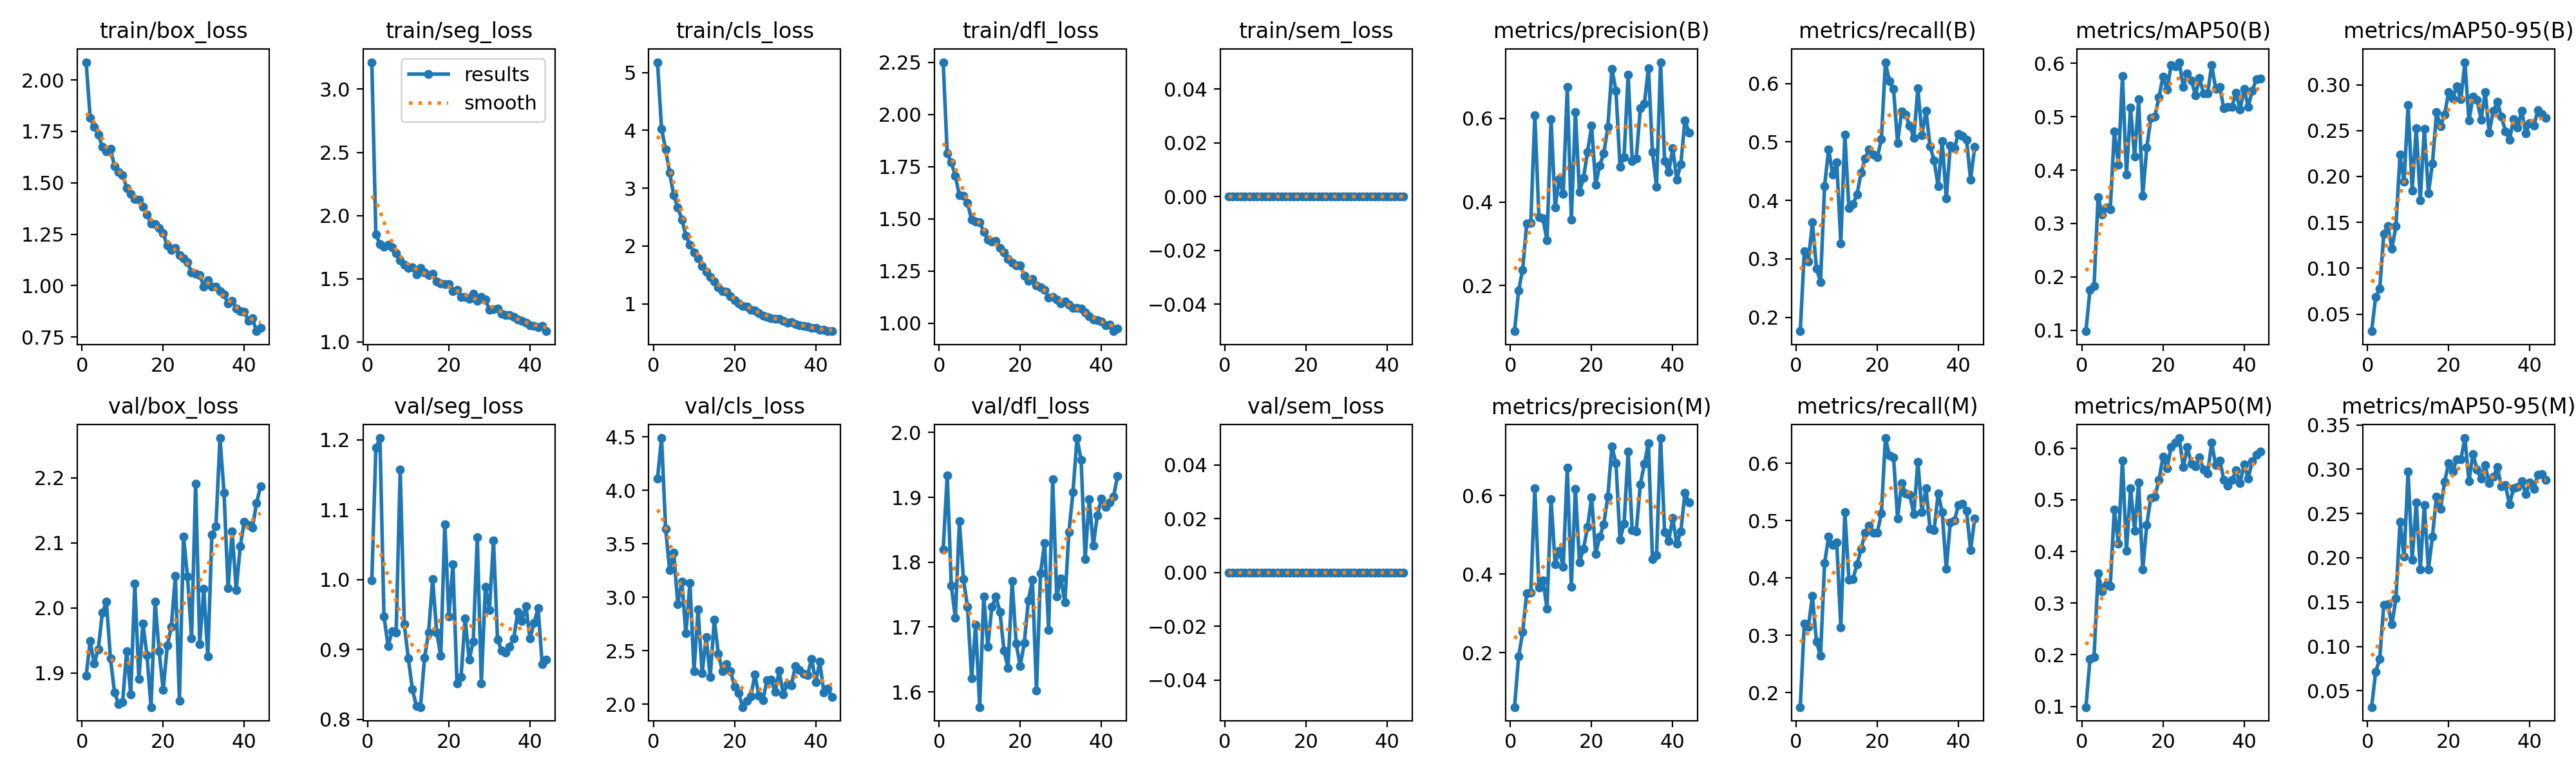


=== Validation Confusion Matrix ===


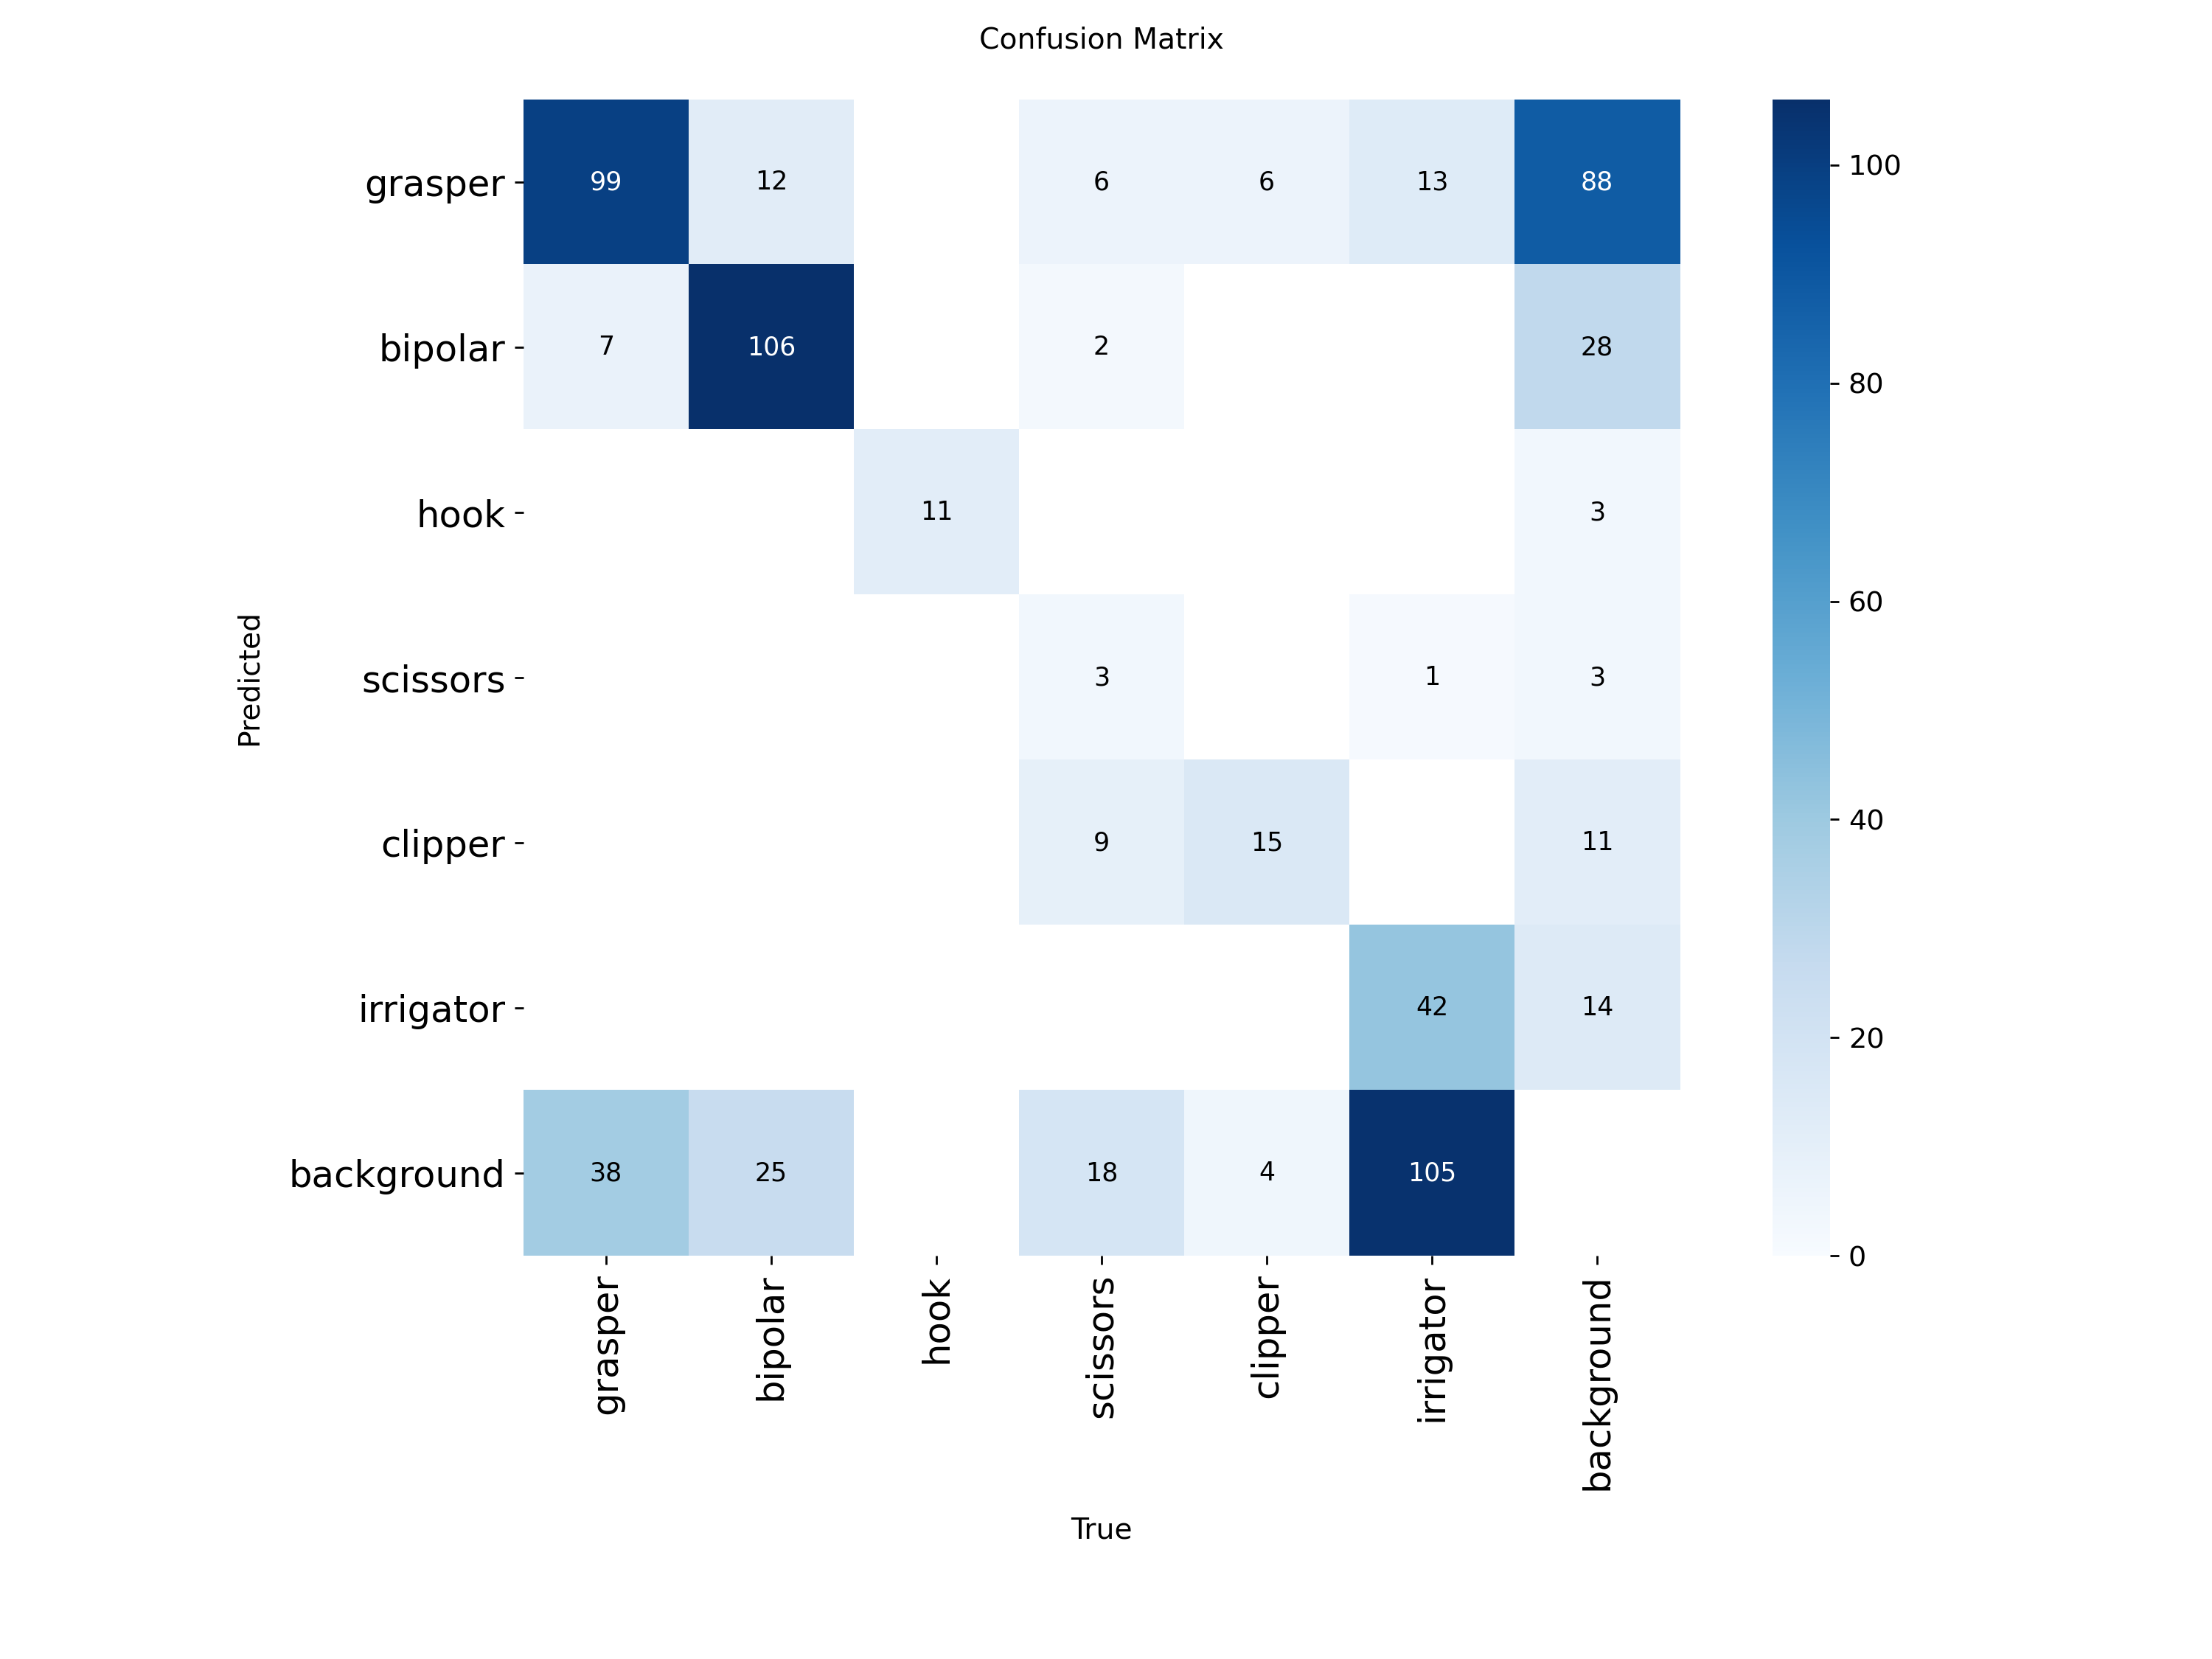

In [27]:
    from IPython.display import Image, display
    from pathlib import Path

    # Path to YOLO training run plots
    run_dir = Path('runs/segment/outputs/train/yolo_seg_cholect50_small')

    if not run_dir.exists():
        print(f'Training directory not found: {run_dir}. Make sure you ran the training cell first.')
    else:
        results_png = run_dir / 'results.png'
        confusion_png = run_dir / 'confusion_matrix.png'

        if results_png.exists():
            print('=== Training Loss & Accuracy Metrics Curves ===')
            display(Image(filename=str(results_png), width=1000))
        else:
            print('Learning curves plot (results.png) not found.')

        if confusion_png.exists():
            print('\n=== Validation Confusion Matrix ===')
            display(Image(filename=str(confusion_png), width=800))
        else:
            print('Confusion matrix plot (confusion_matrix.png) not found.')